Baixando arquivos necessários para a análise com OpenCV e DeepFace
1. `test.jpg` será o arquivo de imagem utilizado na análise
2. Haarcascade será o classificador que auxiliará na identificação de rostos


In [27]:
# Faz uma requisição ao repositório https://github.com/computationalcore/introduction-to-opencv
# e à página do ator Terry Crews na WikiPedia https://pt.wikipedia.org/wiki/Terry_Crews

!wget --no-check-certificate \
  https://upload.wikimedia.org/wikipedia/commons/thumb/5/58/Terry_Crews_by_Gage_Skidmore_5.jpg/960px-Terry_Crews_by_Gage_Skidmore_5.jpg \
  -O test.jpg

!wget --no-check-certificate \
  https://raw.githubusercontent.com/computationalcore/introduction-to-opencv/master/assets/haarcascade_frontalface_default.xml \
  -O haarcascade_frontalface_default.xml

--2026-03-21 00:58:41--  https://upload.wikimedia.org/wikipedia/commons/thumb/5/58/Terry_Crews_by_Gage_Skidmore_5.jpg/960px-Terry_Crews_by_Gage_Skidmore_5.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.153.240, 2620:0:860:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.153.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197336 (193K) [image/jpeg]
Saving to: ‘test.jpg’

test.jpg            100%[===================>] 192.71K  --.-KB/s    in 0.1s    

2026-03-21 00:58:41 (1.32 MB/s) - ‘test.jpg’ saved [197336/197336]

--2026-03-21 00:58:41--  https://raw.githubusercontent.com/computationalcore/introduction-to-opencv/master/assets/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaitin

Como a biblioteca DeepFace não faz parte do pacote de bibliotecas padrão do Google Colab, é necessário instalá-la manualmente

In [20]:
!pip install deepface

Importação das bibliotecas necessárias
- OpenCV
- DeepFace
- Matplotlib
- JSON

In [28]:
import cv2
import json
import matplotlib.pyplot as plt
from deepface import DeepFace

print("Importações feitas com sucesso!")

Importações feitas com sucesso!


Carregando e padronizando a imagem que será utilizada nos testes

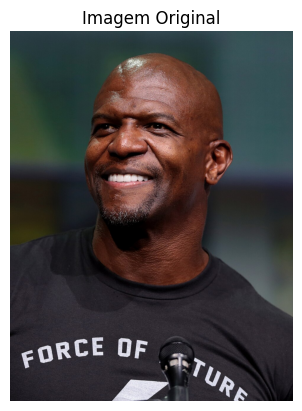

In [53]:
# Carregando a imagem
image = cv2.imread("test.jpg")

# Convertendo a imagem para escala de cinza
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Exibindo a imagem original a fim de comparação
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off") # Desativa os eixos para melhor exibição
plt.title("Imagem Original")
plt.show()

Aplicando a bilbioteca DeepFace para análise dos rostos (emoções, idades, gêneros)

In [37]:
demography = DeepFace.analyze(image, actions = ["emotion", "age", "gender", "race"])

# Exibição bruta dos dados da análise
print("\n", demography)

Action: race: 100%|██████████| 4/4 [00:02<00:00,  1.93it/s]


 [{'emotion': {'angry': np.float32(0.0005339183), 'disgust': np.float32(5.4572284e-12), 'fear': np.float32(0.03448834), 'happy': np.float32(94.77685), 'sad': np.float32(0.00046781998), 'surprise': np.float32(0.008034774), 'neutral': np.float32(5.179627)}, 'dominant_emotion': 'happy', 'region': {'x': 181, 'y': 151, 'w': 424, 'h': 424, 'left_eye': None, 'right_eye': None}, 'face_confidence': 0.96, 'age': 45, 'gender': {'Woman': np.float32(0.01045051), 'Man': np.float32(99.98955)}, 'dominant_gender': 'Man', 'race': {'asian': np.float32(4.4599545e-07), 'indian': np.float32(7.725235e-05), 'black': np.float32(99.99992), 'white': np.float32(4.98391e-11), 'middle eastern': np.float32(8.409852e-12), 'latino hispanic': np.float32(1.133437e-06)}, 'dominant_race': 'black'}]


Utilizando o Cascade Frontl Face para identificar e destacar o rosto da imagem com um quadrdo vermelho e exibindo os dados formatados analisados pelo DeepFace

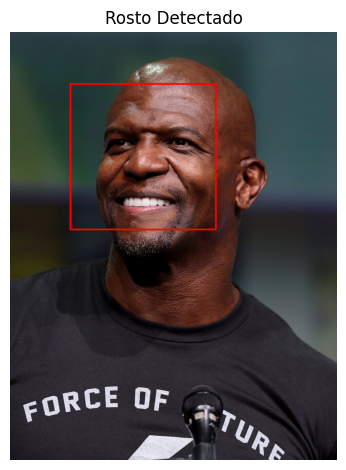

            ANÁLISE COMPLETA            
Idade: 45
Gênero: Homem
Raça/Cor: Negra
Emoção: Feliz


In [77]:
# Carregando o classificador Cascade
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Utilizando a imagem em escala de cinza para detectar a posição relativa do rosto
detected_face = face_cascade.detectMultiScale(image_gray, scaleFactor=1.3, minNeighbors=5)

# Verificando a face detectada
for (start_x, start_y, width, height) in detected_face:
  end_x = start_x + width
  end_y = start_y + height

  # Desenha um retângulo vermelho ao redor do rosto detectado
  cv2.rectangle(
      img = image,
      pt1 = (start_x, start_y),
      pt2 = (end_x, end_y),
      color = [0, 0, 255],
      thickness = 4
  )

# Convertendo as cores da imagem de BGR para RGB e exibindo-a
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Imagem com rosto detectado
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Rosto Detectado")

plt.tight_layout()
plt.show()

# Exibindo os dados formatados analisados pelo DeepFace
print("=" * 40)
print(f"{'ANÁLISE COMPLETA':^40}")
print("=" * 40)

print(f"Idade: {demography[0]['age']}")
print(f"Gênero: {'Homem' if demography[0]['dominant_gender'] == 'Man' else demography[0]['dominant_gender']}")
print(f"Raça/Cor: {'Negra' if demography[0]['dominant_race'] == 'black' else demography[0]['dominant_race']}")
print(f"Emoção: {'Feliz' if demography[0]['dominant_emotion'] == 'happy' else demography[0]['dominant_emotion']}")

Com base nos dados acima, pode-se notar que o DeepFace foi capaz de estipular uma idade média condizente com a aparência física do apresentador e acertou precisamente a sua emoção, raça/cor e o seu gênero. O mesmo vale para o OpenCV, que também foi capaz de localizar corretamente o rosto de Terry Crews.